In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'

In [19]:
from data import load_data, regions, popls
from sklearn.impute import KNNImputer, SimpleImputer

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]
df = df.iloc[np.argsort(df.index + 1e7*df['POP-ID'].apply(popls.index))].reset_index(drop=True)
# regions = sorted(df['region'].unique())
# popls = sorted(df['popl'].unique())

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer(n_neighbors=5)
X = imputer.fit_transform(df_chs)

# How distance is distributed

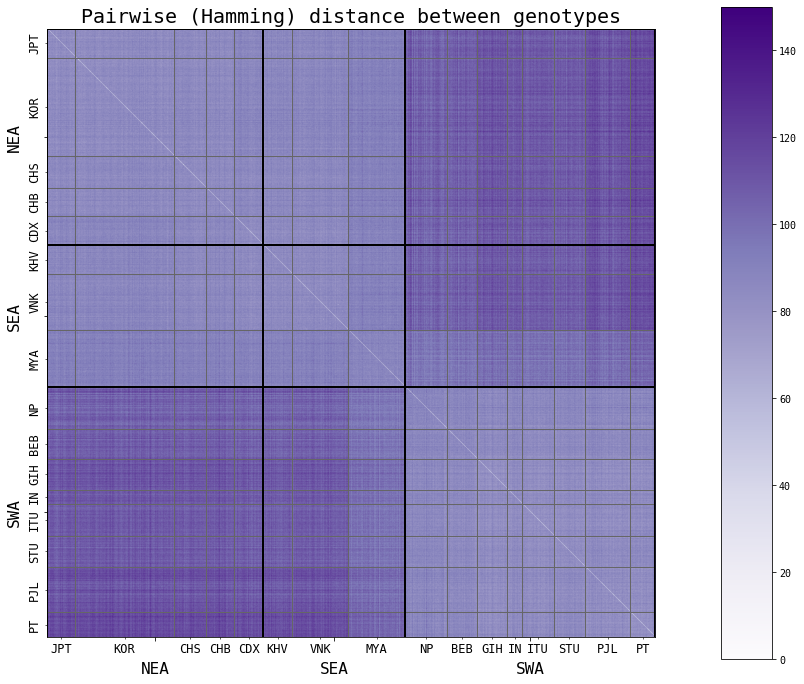

In [20]:
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import LabelEncoder

dist_mat = pairwise_distances(X, metric='manhattan') / 2

# region_bdry = np.where(np.diff(LabelEncoder().fit_transform(df['Geographic region']), prepend=-1, append=-1) != 0)[0]
# popl_bdry = np.where(np.diff(LabelEncoder().fit_transform(df['POP-ID']), prepend=-1, append=-1) != 0)[0]
region_bdry = np.cumsum(np.fromiter(((df['Geographic region'] == region).sum() for region in [''] + regions), dtype=np.int32))
popl_bdry = np.cumsum(np.fromiter(((df['POP-ID'] == popl).sum() for popl in [''] + popls), dtype=np.int32))
region_center = (region_bdry[1:] + region_bdry[:-1])/2 + 0.5
popl_center = (popl_bdry[1:] + popl_bdry[:-1])/2

fig, axs = plt.subplots(ncols=2, figsize=(12+1, 12), gridspec_kw={'width_ratios': [12, 1]})
ax = axs[0]
ax_img = ax.imshow(dist_mat, cmap='Purples')
ax.set_xlim(auto=False); ax.set_ylim(auto=False)
for i in popl_bdry:
    ax.axhline(y=i, xmin=0, xmax=1, color='#666666', linewidth=1)
    ax.axvline(x=i, ymin=0, ymax=1, color='#666666', linewidth=1)
for i in region_bdry:
    ax.axhline(y=i, xmin=0, xmax=1, color='#000000', linewidth=2)
    ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=2)
ax.set_xticks(region_center); ax.set_yticks(region_center)
ax.set_xticklabels(['\n' + el for el in regions], fontsize=16)
ax.set_yticklabels([el + '\n' for el in regions], fontsize=16, rotation=90, va='center')
ax.set_xticks(popl_center, minor=True); ax.set_yticks(popl_center, minor=True)
ax.set_xticklabels(popls, fontsize=12, minor=True)
ax.set_yticklabels(popls, fontsize=12, minor=True, rotation=90, va='center')

ax.set_title('Pairwise (Hamming) distance between genotypes', fontsize=20)
plt.colorbar(ax_img, cax=axs[1])
plt.show(); plt.close()

## Visualization by UMAP

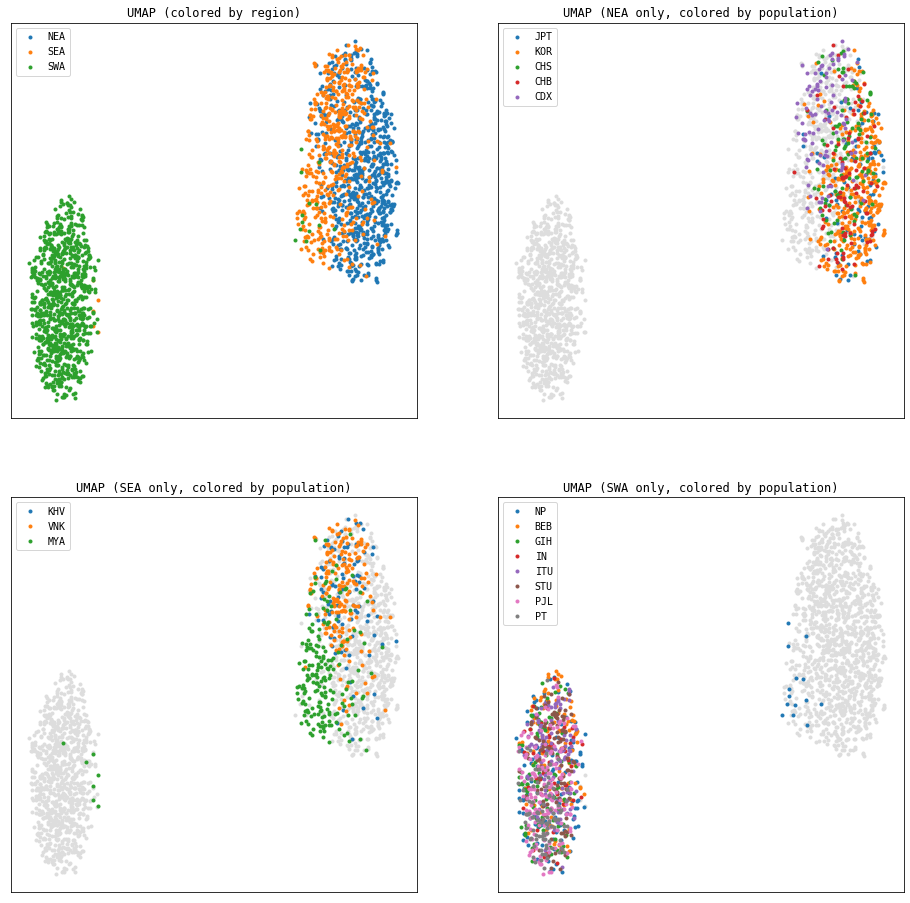

In [21]:
from umap import UMAP
reducer = UMAP(
    n_components=2, 
    metric='manhattan',
    random_state=42
)
X_red = reducer.fit_transform(X)
X_red = pd.DataFrame(X_red, index=df.index)

s = 9.

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))

ax = axs[0, 0]
for i, reg in enumerate(regions):
    ax.scatter(*X_red[df['Geographic region'] == reg].values.T, color=f'C{i}', s=s, label=reg)  
ax.set_title('UMAP (colored by region)')

ax = axs[0, 1]
ax.scatter(*X_red[df['Geographic region'] != 'NEA'].values.T, color='#dddddd', s=s)
for i, pop in enumerate(df.loc[df['Geographic region'] == 'NEA', 'POP-ID'].unique()):
    ax.scatter(*X_red[df['POP-ID'] == pop].values.T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (NEA only, colored by population)')

ax = axs[1, 0]
ax.scatter(*X_red[df['Geographic region'] != 'SEA'].values.T, color='#dddddd', s=s)
for i, pop in enumerate(df.loc[df['Geographic region'] == 'SEA', 'POP-ID'].unique()):
    ax.scatter(*X_red[df['POP-ID'] == pop].values.T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (SEA only, colored by population)')

ax = axs[1, 1]
ax.scatter(*X_red[df['Geographic region'] != 'SWA'].values.T, color='#dddddd', s=s)
for i, pop in enumerate(df.loc[df['Geographic region'] == 'SWA', 'POP-ID'].unique()):
    ax.scatter(*X_red[df['POP-ID'] == pop].values.T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (SWA only, colored by population)')

for ax in axs.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend()
plt.show(); plt.close()

## Some supervised tests

In [5]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

model = SVC(C=1.)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Geographic region'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model.fit(X_train, y_train)
print( np.mean(model.predict(X_train) == y_train) )
print(np.mean(model.predict(X_test) == y_test))

0.9368421052631579
0.8576051779935275


In [6]:
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = KNeighborsClassifier(n_neighbors=25, metric='manhattan')
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.8437246963562753
0.8058252427184466


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, a

## Fuzzy Clustering

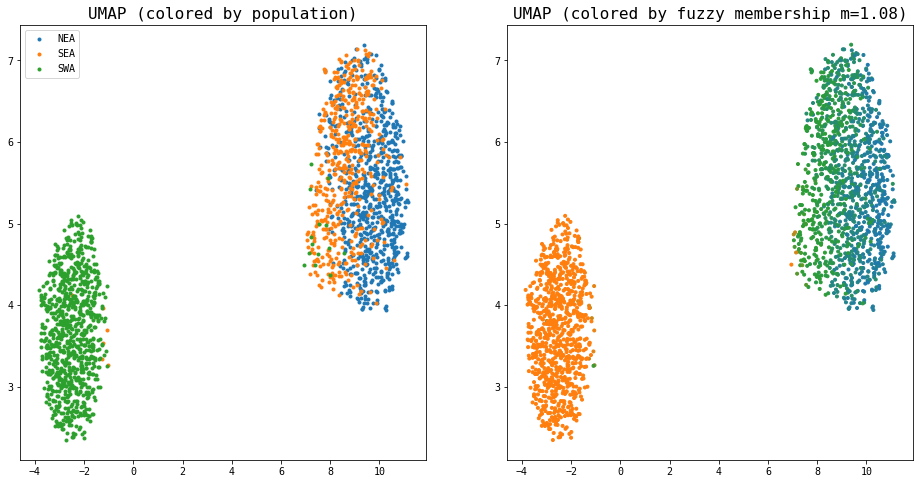

In [24]:
from pyclustering.cluster.fcm import fcm
from matplotlib.colors import to_rgb

m = 1.08

clusterer = fcm(data=X, initial_centers=np.random.default_rng(31).choice(X, 3, replace=False, axis=0), m=m)
clusterer.process()
membership = clusterer.get_membership()

default_3colors = np.array([to_rgb(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color'][:3]])

s = 9.

fig, axs = plt.subplots(ncols=2, figsize=(16, 8))
ax = axs[0]
for i, region in enumerate(regions):
    mask_tmp = (df['Geographic region'] == region).values.astype(bool)
    ax.scatter(*X_red[mask_tmp].values.T, s=s, c=f'C{i}', label=region)
ax.legend()
ax.set_title('UMAP (colored by population)', fontsize=16)


ax = axs[1]
ax.scatter(*X_red.values.T, s=s, c=membership @ default_3colors)
ax.set_title(f'UMAP (colored by fuzzy membership m={m})', fontsize=16)

plt.show(); plt.close()

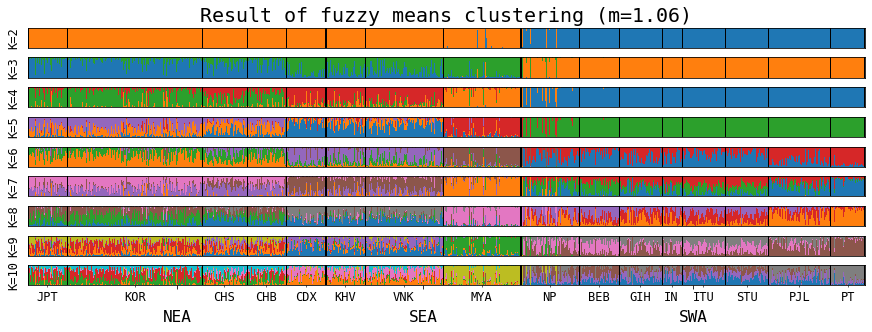

In [32]:
m = 1.08

for m in (1.06, ):
# for m in (1.06, 1.08, 1.2):
    k_min, k_max = 2, 10

    fig, axs = plt.subplots(nrows=k_max-k_min+1, figsize=(12, 0.5*(k_max-k_min+1)), layout='constrained')
    for k in range(k_min, k_max+1):
        ax = axs[k-k_min]

        clusterer = fcm(data=X, initial_centers=np.random.default_rng(31).choice(X, k, replace=False, axis=0), m=m)
        clusterer.process()
        membership = clusterer.get_membership()
        ms_bar = np.array(membership)
        ms_bar = np.concatenate([np.zeros((X.shape[0], 1)), np.cumsum(ms_bar, axis=1)], axis=1)
        for i in range(k):
            ax.bar(np.arange(X.shape[0]), ms_bar[:, i+1]-ms_bar[:, i], width=1, bottom=ms_bar[:, i])
        
        ax.set_xlim(0, X.shape[0])
        for i in popl_bdry:
            ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=1)
        for i in region_bdry:
            ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=2)
        ax.set_ylabel(f'K={k}', fontsize=12)
        if k == k_min:
            ax.set_title(f'Result of fuzzy means clustering (m={m})', fontsize=20)
        if k < k_max:
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.set_xticks(region_center); ax.set_yticks([])
            ax.set_xticklabels(['\n' + el for el in regions], fontsize=16)
            ax.set_xticks(popl_center, minor=True)
            ax.set_xticklabels(popls, fontsize=12, minor=True)
    plt.show(); plt.close()

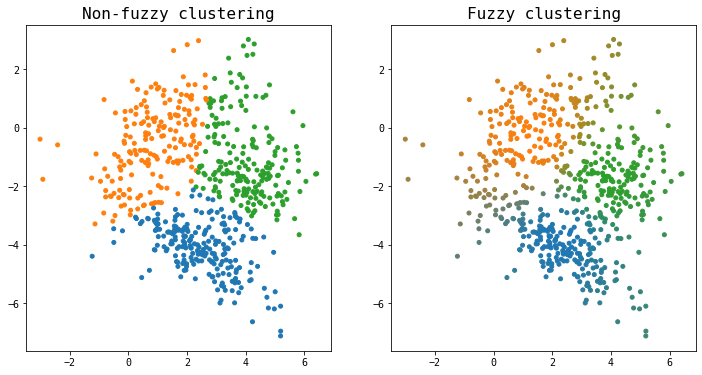

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))
rng = np.random.default_rng(42)
pts = np.stack([
    rng.multivariate_normal([1.5, 0], [[2, 1], [1, 2]], (200, )), 
    rng.multivariate_normal([4, -2], [[1, 0], [0, 1]], (200, )), 
    rng.multivariate_normal([2, -4], [[2.2, -1.3], [-1.3, 1.1]], (200, ))
    ], axis=0)
pts = pts.reshape(600, 2)

for i in range(2):
    ax = axs[i]

    clusterer = fcm(data=pts, initial_centers=rng.choice(pts, 3, replace=False, axis=0), m=1.4*i+1.000001)
    clusterer.process()

    if i == 0:
        ax.scatter(*pts.T, s=16., c=clusterer.get_membership() @ default_3colors)
        ax.set_title('Non-fuzzy clustering', fontsize=16)
    else:
        ax.scatter(*pts.T, s=16., c=clusterer.get_membership() @ default_3colors[[0, 2, 1]])
        ax.set_title('Fuzzy clustering', fontsize=16)


plt.show(); plt.close()

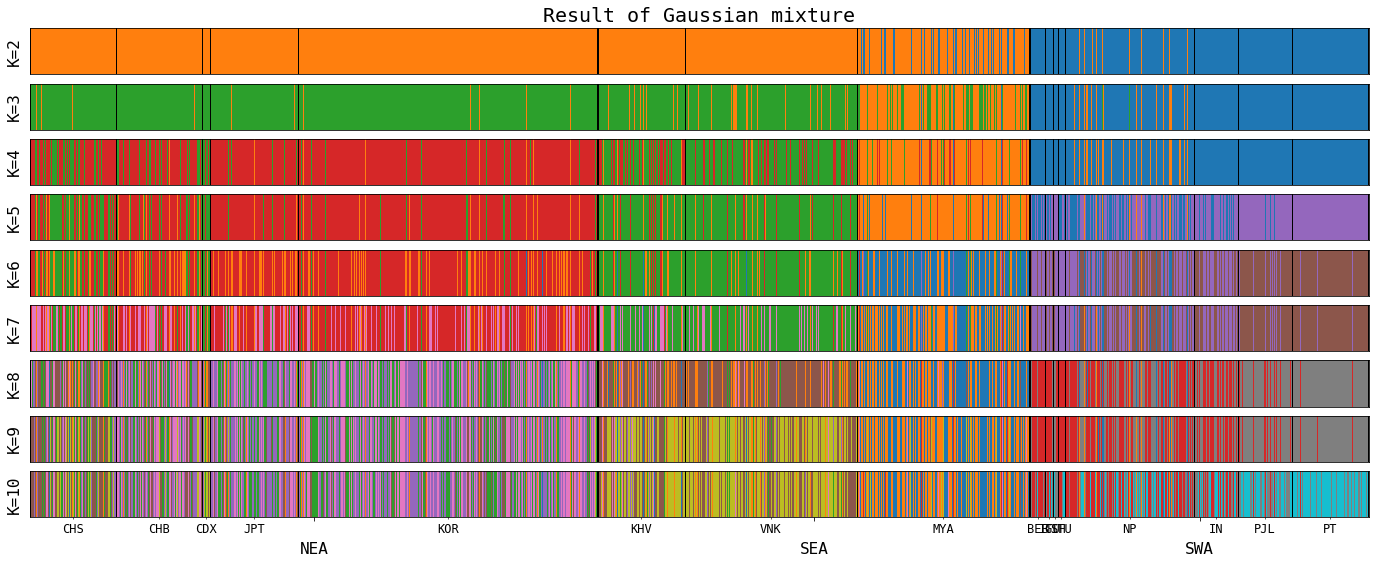

In [16]:
from sklearn.mixture import GaussianMixture
from scipy.special import softmax

k_min, k_max = 2, 10
fig, axs = plt.subplots(nrows=k_max-k_min+1, figsize=(24, k_max-k_min+1))
for k in range(k_min, k_max+1):
    ax = axs[k-k_min]

    model = GaussianMixture(n_components=k, random_state=42)
    model.fit(X)
    # w, mean, cov = model.weights_, model.means_, model.covariances_

    # log_likelihood = -0.5*np.einsum('ilj,ilk,ljk->il', X[:, np.newaxis] - mean, X[:, np.newaxis] - mean, np.linalg.inv(cov)) \
    #     - 0.5*np.linalg.slogdet(2*np.pi*cov)[1] + np.log(w)
    # proba = softmax(log_likelihood, axis=1)
    proba = model.predict_proba(X)
    

    ms_bar = np.array(proba)
    ms_bar = np.concatenate([np.zeros((X.shape[0], 1)), np.cumsum(ms_bar, axis=1)], axis=1)
    for i in range(k):
        ax.bar(np.arange(X.shape[0]), ms_bar[:, i+1]-ms_bar[:, i], width=1, bottom=ms_bar[:, i])
    
    ax.set_xlim(0, X.shape[0])
    for i in popl_bdry:
        ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=1)
    for i in region_bdry:
        ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=2)
    ax.set_ylabel(f'K={k}', fontsize=16)
    if k == k_min:
        ax.set_title('Result of Gaussian mixture', fontsize=20)
    if k < k_max:
        ax.set_xticks([]); ax.set_yticks([])
    else:
        ax.set_xticks(region_center); ax.set_yticks([])
        ax.set_xticklabels(['\n' + el for el in regions], fontsize=16)
        ax.set_xticks(popl_center, minor=True)
        ax.set_xticklabels(popls, fontsize=12, minor=True)
plt.show(); plt.close()

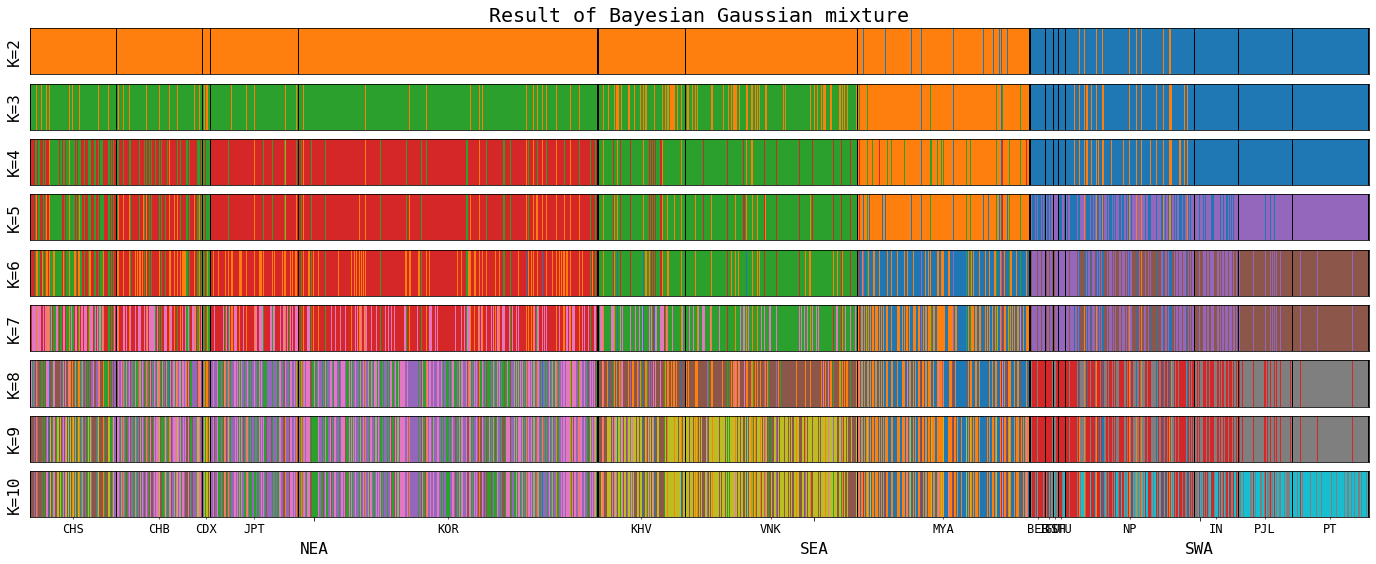

In [17]:
from sklearn.mixture import BayesianGaussianMixture
from scipy.special import softmax

k_min, k_max = 2, 10
fig, axs = plt.subplots(nrows=k_max-k_min+1, figsize=(24, k_max-k_min+1))
for k in range(k_min, k_max+1):
    ax = axs[k-k_min]

    model = BayesianGaussianMixture(n_components=k, random_state=42)
    model.fit(X)
    w, mean, cov = model.weights_, model.means_, model.covariances_

    # log_likelihood = -0.5*np.einsum('ilj,ilk,ljk->il', X[:, np.newaxis] - mean, X[:, np.newaxis] - mean, np.linalg.inv(cov)) \
    #     - 0.5*np.linalg.slogdet(2*np.pi*cov)[1] + np.log(w)
    # proba = softmax(log_likelihood, axis=1)
    proba = model.predict_proba(X)

    ms_bar = np.array(proba)
    ms_bar = np.concatenate([np.zeros((X.shape[0], 1)), np.cumsum(ms_bar, axis=1)], axis=1)
    for i in range(k):
        ax.bar(np.arange(X.shape[0]), ms_bar[:, i+1]-ms_bar[:, i], width=1, bottom=ms_bar[:, i])
    
    ax.set_xlim(0, X.shape[0])
    for i in popl_bdry:
        ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=1)
    for i in region_bdry:
        ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=2)
    ax.set_ylabel(f'K={k}', fontsize=16)
    if k == k_min:
        ax.set_title('Result of Bayesian Gaussian mixture', fontsize=20)
    if k < k_max:
        ax.set_xticks([]); ax.set_yticks([])
    else:
        ax.set_xticks(region_center); ax.set_yticks([])
        ax.set_xticklabels(['\n' + el for el in regions], fontsize=16)
        ax.set_xticks(popl_center, minor=True)
        ax.set_xticklabels(popls, fontsize=12, minor=True)
plt.show(); plt.close()